# Spectrum Adapted EM algorithmによるスペクトルデータフィット
このノートは、pythonコードであるSpectrumAdaptedEMGMM packageの利用法に関するチュートリアルです。このパッケージは、スペクトルデータを混合ガウス分布でフィッティングするためのツールです。  
 
フィッティングにはスペクトル解析用EMアルゴリズム[Sci. Tech. Adv. Mater. 20, 733-735 (2019)]を用います。通常のEMアルゴリズムをこの問題に適用する場合、データはn番目のイベントでの観測エネルギー$E_n$に対する集合$E_{\rm 1D}=\{E_n\}_{n=1}^{N}$を用いますが、スペクトル解析用では$E_{\rm 1D}$をヒストグラム形式にしたデータ$E_{\rm 2D} = \{E^{\rm bin}_n, w_n\}_{n=1}^{N_{\rm bin}}$を用います。ただし、$E_n^{\rm bin}$はチャネル$n$のエネルギー値, $w_n$はチャネル$n$の重み, $N_{\rm bin}$はチャネル数です。そのため入力であるデータファイルは、ndarray (2, n)形式（ndarray([[energy],[weight]])）である必要があります。 

混合ガウス分布の成分数Kはデフォルトでは２ですが、任意の正の整数に設定することができます。このチュートリアルでは、テストデータとして2成分混合ガウス分布から生成したダミーデータと、C1s に関するXPSデータを用意してます。

## チュートリアルの内容
0. パッケージのインストールとパス設定
1. パッケージのimportとダミーデータ生成
2. 通常のEMアルゴリズムによるデータフィッティング時間
3. Spectrum-Adapted EM Algorithmによるデータフィッティング
4. フィッティングサマリーの表示
5. XPSデータのフィッティング

## 0. パッケージのインストールとパス設定

本パッケージは、フォルダ内にある"EMPeaks"というフォルダにパスを通せば利用することができます。ご自身のシステムに自動的にインストールするには、配布パッケージの親フォルダにあるsetup.pyを利用します。インストール手順は以下のとおりです。
   1. windowsの場合はコマンドプロンプト, macOSの場合はターミナルを開き、cd コマンドで配布フォルダに移動します。
   2. `python setup.py install` を実行します

これでシステムにインストールされます。

もしインストールがうまくいかない場合、もしくは直接モジュールにパスを通したい場合には、以下の手順をふんでください。
   1. 配布パッケージの中にあるEMPeaksフォルダをモジュール置き場に移してください。
   2. モジュール置き場のフルパスを記録してください。<br>
     （参照：mac: https://aprico-media.com/posts/1578/ ,windows: https://windows-podcast.com/sundayprogrammer/archives/80 ）
   3. jupyter notebookで以下のセルを実行してください（setup.pyを使った場合には不要です。）
      ``` python
         import sys
         sys.path.append("フルパス")
      ```
Windowsの場合、パス区切りがバックスラッシュ"\\"で表示されます。バックスラッシュはエスケープされてしまうため、全てスラッシュ"/"で置き換えてください。これでも問題なく読み込みます。

これで本パッケージを使用する準備が整いました。

## テスト1. 通常のEMアルゴリズムによるフィッティング

-- test_data information ---
model:               Gaussian mixture model of K = 2
mu(means):           [3.5 6.5]
sigma^2(variances):  [1.4 0.7]
pi(mixing ratio):    [0.3 0.7]
n(data number):      5000
bins:                500


---data1D---
shape:  (5000,)

initial param: [{'mu': 6.79115948169, 'sigma': 0.5953733050654489, 'pi': 0.9253151566278011}, {'mu': 6.79115948169, 'sigma': 0.5410515147506255, 'pi': 0.07468484337219894}]

**** Sampling: 0 ****
Start Fitting by conventional EM algorithm.

Log Likelihood is converged with iteration  220
Log Likelihood:  -8991.036623889235

-- Converged parameters --
mu(means):          [3.50210074 6.48108364]
sigma^2(variance):  [1.49079949 0.68184668]
pi(mixing ratio):   [0.29717431 0.70282569]

**** Sampling: 1 ****
Start Fitting by conventional EM algorithm.

Log Likelihood is converged with iteration  202
Log Likelihood:  -8991.036623889244

-- Converged parameters --
mu(means):          [3.50210076 6.48108364]
sigma^2(variance):  [1.49079951 0

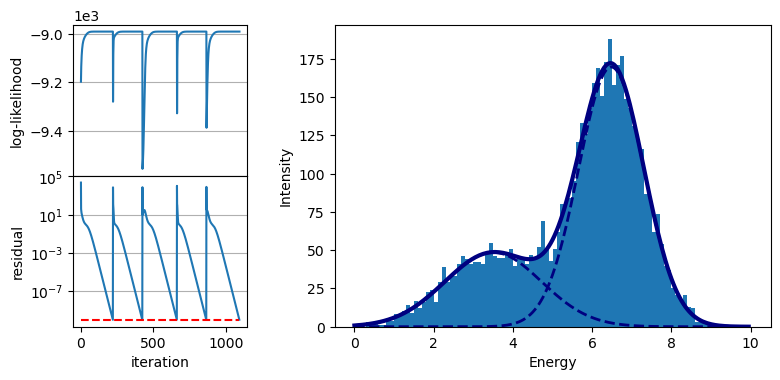

In [2]:
%matplotlib inline
from EMPeaks import GaussianMixture
test = GaussianMixture.Tests
%time test.test_em(N=5000,sampling=5)

## 2. Spectrum-adapted EMアルゴリズムによるフィッティング

-- test_data information ---
model:               Gaussian mixture model of K = 2
mu(means):           [3.5 6.5]
sigma^2(variances):  [1.4 0.7]
pi(mixing ratio):    [0.3 0.7]
n(data number):      50000
bins:                500


---data2D---
shape:  (2, 500)
initial param: [{'mu': 4.290716766363014, 'sigma': 0.8255792057053359, 'pi': 0.5409298665081106}, {'mu': 0.3576281720717249, 'sigma': 0.291979579639814, 'pi': 0.4590701334918894}]

**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 179
Log Likelihood:  -90627.28433119481

-- Converged parameters --
mu(means):          [3.42526661 6.47846086]
sigma^2(variance):  [1.30706956 0.72806762]
pi(mixing ratio):   [0.29069723 0.70930277]

**** Sampling: 1 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 175
Log Likelihood:  -90627.28433119475

-- Converged parameters --
mu(means):          [3.42526658 6.47846085]
sigma^2(variance): 

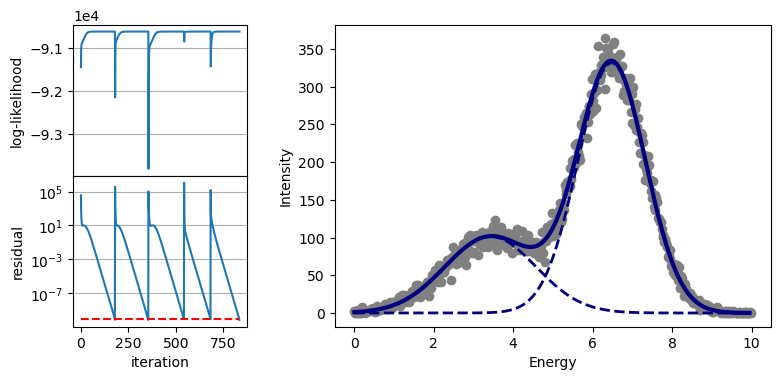

In [3]:
%time test.test_spectrum_adapted_em(N=50000,sampling=5)

## 3. XPS 実験データに対するフィッティング
EMPeaks_1.0.0にあるGFET0126_25V_C1s.txtといるファイルをこのjupyter notebookのあるフォルダに移してから次のコマンドを実行してください。

initial param: [{'mu': 696.7305069161, 'sigma': 0.7567962495399464, 'pi': 0.9835589841033171}, {'mu': 712.5571408949708, 'sigma': 0.6563134668714886, 'pi': 0.008301617149882859}, {'mu': 717.1204012254191, 'sigma': 0.5683918186388135, 'pi': 0.00813939874680004}]

**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 284
Log Likelihood:  -13051919.201819692

-- Converged parameters --
mu(means):          [697.98950421 707.58084461 712.83885902]
sigma^2(variance):  [ 2.75753934 20.44952797  0.40751376]
pi(mixing ratio):   [0.11172843 0.39625814 0.49201344]

**** Sampling: 1 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 124
Log Likelihood:  -13224938.919959329

-- Converged parameters --
mu(means):          [705.13791602 712.81999578 719.50524589]
sigma^2(variance):  [30.8139015   0.44561672  0.31575947]
pi(mixing ratio):   [0.48679917 0.51082737 0.00237346]

**** Sampling: 2 ****

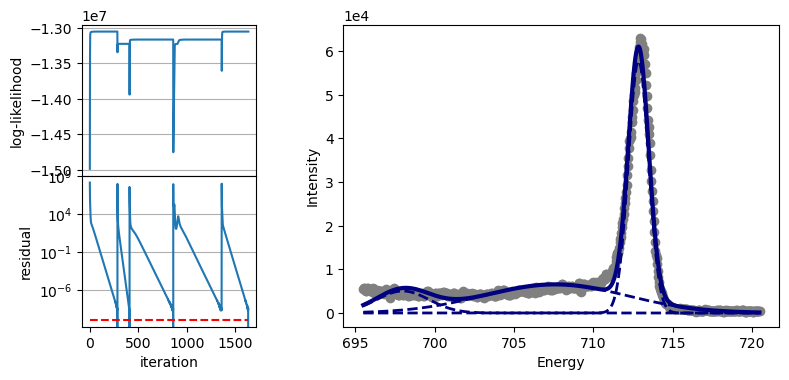

In [4]:
fpath = 'GFET0126_25V_C1s.txt'
%time test.test_exp_data(file=fpath, sampling=5)

### 1. パッケージのimportとダミーデータ生成
まずこのチュートリアルで使用するパッケージをimportします。また、今回アニメーションを利用するためにマジックコマンドを設定しています。この設定はjupyter lab上では機能しないことに注意してください。そのためjupyter lab上ではアニメーションをインタラクティブに実行せず、gifなどの形式で保存して確認することを推奨します。   

ここでは３つのパッケージをimportしています。まずSpectrumAdaptedGMMFit, GMMFitの二つです。前者がSpectrum-Adapted EMアルゴリズム, 後者が通常のEMアルゴリズムによるデータフィッティングクラスです。次にGenTestDataGMM2は、２成分混合ガウス分布に基づいたダミーデータを生成するためのクラスです。

まず、GenTestDataGMM2のインスタンスを作成します。引数は生成するデータ数Nです。このクラスはいくつかのメソッドを持っており、データ生成に関する情報やデータ頻度を散布図にしたものの描画が可能です。データ自体は[0, 10]の区間で混合ガウス分布にしたがってN個のイベントを生成しています。イベントそのもののデータは、dat.data1D, [0, 10]区間を分割してヒストグラム形式である２次元データに加工したものがdat.data2Dです。

plotのサイズは、pdi(デフォルト=100)を変更することで拡大・縮小できます。お手元の環境に合うようサイズを変更してください。


-- test_data information ---
model:               Gaussian mixture model of K = 2
mu(means):           [3.5 6.5]
sigma^2(variances):  [1.4 0.7]
pi(mixing ratio):    [0.3 0.7]
n(data number):      5000
bins:                500


---data1D---
shape:  (5000,)
---data2D---
shape:  (2, 500)


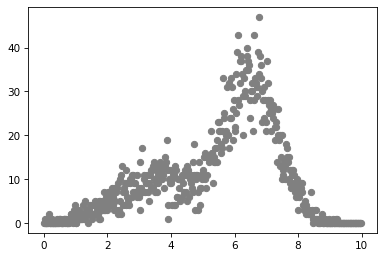

In [5]:
from EMPeaks import GaussianMixture

dat = GaussianMixture.TestData(5000)
dat.show_info()
print("---data1D---")
print("shape:  {}".format(dat.data1D.shape))
print("---data2D---")
print("shape:  {}".format(dat.data2D.shape))
dat.plot(dpi=75)

### 2. 通常のEMアルゴリズムによるデータフィッティング時間
先ほど生成したデータに対して通常のEMアルゴリズムを適用してみましょう。通常は、イベント生データを利用するため１次元配列を入力します。また、成分数Kはデフォルトでは２です。N=500, 1000, 5000と変更して実行時間を比較します。

In [6]:
for i in [10000, 50000, 100000]:
    dat = GaussianMixture.TestData(i)
    em = GaussianMixture.EM(dat.data1D)
    %time em.fit()


**** Sampling: 0 ****
Start Fitting by conventional EM algorithm.

Log Likelihood is converged with iteration  101
Log Likelihood:  -18012.159052008443

-- Converged parameters --
mu(means):          [3.47089264 6.48956888]
sigma^2(variance):  [1.262053   0.70091095]
pi(mixing ratio):   [0.29514498 0.70485502]


*** Finishing 1 sampling ***
maximum-likelihood model is sampled with index 0
log-likelihood: -18012.159052008443

Model parameters
mu(means):          [3.47089264384095, 6.489568884175317]
sigma^2(variance):  [1.2620529976857633, 0.700910945965434]
pi(mixing ratio):   [0.29514497566541714, 0.7048550243345829]
CPU times: user 153 ms, sys: 3.37 ms, total: 157 ms
Wall time: 157 ms

**** Sampling: 0 ****
Start Fitting by conventional EM algorithm.

Log Likelihood is converged with iteration  138
Log Likelihood:  -90115.33519852396

-- Converged parameters --
mu(means):          [3.52990653 6.4921991 ]
sigma^2(variance):  [1.41372922 0.69848872]
pi(mixing ratio):   [0.29895111 0.7

EMアルゴリズムの初期値は乱数で生成しているため、初期値依存性やダミーデータにも依存してiterationの回数も変化しますが概ねデータ数Nに比例して計算時間が増加していくことがわかります。S/N比を高めようとイベント数を増やすと、EMアルゴリズムの計算時間が著しく増加してしまい、実際のXPSなどのイベント数($10^{x}程度$)に適用するのは現実的ではありません。

### 3. Spectrum-Adapted EM Algorithmによるデータフィッティング
では、Spectrum-Adapted EM アルゴリズムでフィッティングを行ってみましょう。次のセルではデータ数を500, 1000, 5000, 500000と４パターン実行します。実行時間にどの程度差がであるでしょうか？

In [7]:
for i in [500, 1000, 5000, 500000]:
    dat = GaussianMixture.TestData(i)
    adapted_em = GaussianMixture.SpectrumAdaptedEM(dat.data2D, K=2)
    %time adapted_em.fit()


**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 123
Log Likelihood:  -913.2658839461551

-- Converged parameters --
mu(means):          [3.5037347  6.46633635]
sigma^2(variance):  [1.34181512 0.75260902]
pi(mixing ratio):   [0.30693845 0.69306155]


*** Finishing 1 sampling ***
maximum-likelihood model is sampled with index 0
log-likelihood: -913.2658839461551

Model parameters
mu(means):          [3.503734703922402, 6.46633635277461]
sigma^2(variance):  [1.3418151197589954, 0.7526090177605609]
pi(mixing ratio):   [0.30693844821389066, 0.6930615517861095]
CPU times: user 68.4 ms, sys: 4.73 ms, total: 73.2 ms
Wall time: 70.4 ms

**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 140
Log Likelihood:  -1834.7734840425899

-- Converged parameters --
mu(means):          [3.52293533 6.45619765]
sigma^2(variance):  [1.34998742 0.77817617]
pi(mixing ratio):   [0.313

データ数を変化させても実行時間はほとんど変化しないことがわかったはずです。これは、Spectrum-Adapted EM algorithmの計算量がデータ数に依存せず、ヒストグラムのビン数に依存するよう設計されているからです。上記のダミーデータではいずれも同じビン数で生成されているために計算量がほとんど変化していません。そのため同じビン数（もしくはチャネル数）であれば、S/N比に関わらず高速にフィットが可能であることがわかります。

### 4. フィッティングサマリーの表示
最後にフィッティング結果を図示して結果の妥当性を確認しましょう。フィッティング結果の表示には４つのメソッドを用意しています。

#### get_gmm_param()
フィッティングの結果得られたパラメータを返します

In [8]:
adapted_em.get_gmm_param()

--Parameters of GMM--
mu(means):           [3.4640642640222987, 6.482665271766428]
sigma^2(variance):   [1.3379018216605936, 0.7041198258560787]
pi(mixing ratio):    [0.2956766236233661, 0.7043233763766339]




#### fit_plot_fitting_summary(dpi=100, save=False)    
   対数尤度と残差尤度の残差の履歴、そしてデータとフィッティング曲線を返します。  
   save=Trueとするとpng形式で保存ができます。

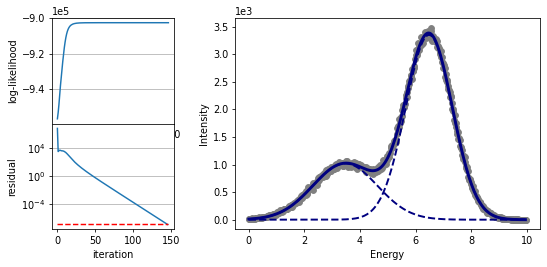

In [9]:
adapted_em.plot_fitting_summary(dpi=70)

#### plot_param_history(dpi=100, save=False)  
EMアルゴリズムによる最適化の過程で得られた、パラメータの履歴を表示します。

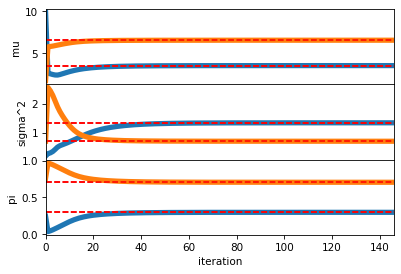

In [10]:
adapted_em.plot_param_history(dpi=75)

#### plot_param_history(dx=0.05, dpi=100, save=False, interval=100, repeat_delay=1500)  
EMアルゴリズムによる最適化の過程で得られた、フィッティング関数の履歴を表示します。  
これはgifアニメーション形式で保存が可能です。jupyter notebookでは`%matplotlib nbagg`を設定することで表示が可能です。しかし、jupyter labではこの機能はサポートされていないため、画像で保存ののちにmarkdownで表示をするなど、別の手段を取る必要があります。

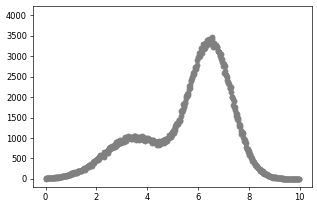

In [11]:
ani = adapted_em.ani_gmm_history(dpi=60, save=False)

[markdownへの埋め込み例]
記法：`<div class="pull-left">![Animated GIF](test.gif) <div>`
<div class="pull-left">![Animated GIF](ani_gmm_history.gif) <div>

### 5. XPSデータのフィッティング
最後に実データに対してフィッティングを行います。'GFET0126_25V_C1s.txt'というファイルにXPSの測定データが含まれています。装置からの出力データは装置のセッティングなどメタデータも含んでいるため、それらを除去してスペクトルデータのみ取り出すような関数も必要になります。今回のデータに対しては、FileIOというメソッドを使ってきりだせるようにしてあります。ただしフォーマットはGFETに限定されているため、他の装置で取得したデータはあたらめて読み込み関数を設計する必要があります。FileIOは、file_io.pyを編集してオプションを追加できます。編集後は、setup.pyを再度実行してシステムにインストールし、jupyter notebookをリスタートしてください。

[[ 695.5         695.53644288  695.57288577 ...  720.3904897
   720.42693259  720.46337547]
 [5612.         5784.         5636.         ...  520.
   491.          539.        ]]


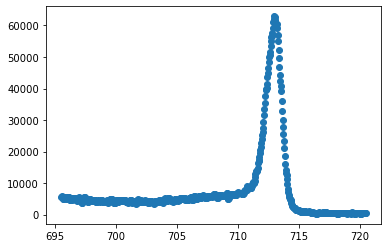

In [12]:
from EMPeaks import FileIO
io = FileIO('GFET0126_25V_C1s.txt', 'GFET')
print(io.data2d)
io.plot()

In [13]:
adapted_em = GaussianMixture.SpectrumAdaptedEM(io.data2d, K=3)
adapted_em.gmm_mu_ = [710, 711, 712.83886715]
%time adapted_em.fit()


**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 274
Log Likelihood:  -13051919.201820608

-- Converged parameters --
mu(means):          [697.9895102  707.58085152 712.83885909]
sigma^2(variance):  [ 2.75755305 20.44949656  0.40751363]
pi(mixing ratio):   [0.11172875 0.39625788 0.49201337]


*** Finishing 1 sampling ***
maximum-likelihood model is sampled with index 0
log-likelihood: -13051919.201820608

Model parameters
mu(means):          [697.9895102012622, 707.5808515248146, 712.8388590880227]
sigma^2(variance):  [2.7575530540594793, 20.449496559918064, 0.4075136301665433]
pi(mixing ratio):   [0.11172874944249266, 0.3962578812061205, 0.49201336935138684]
CPU times: user 251 ms, sys: 6.49 ms, total: 257 ms
Wall time: 261 ms


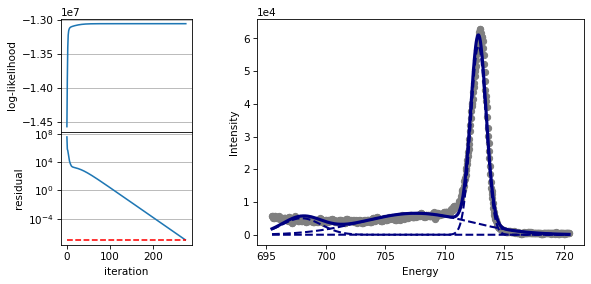

In [14]:
fig = adapted_em.plot_fitting_summary(75, save=True)

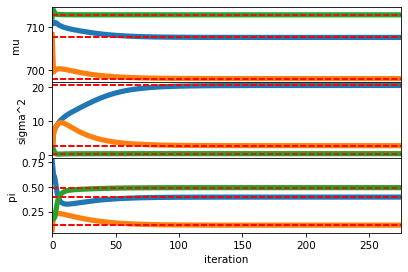

In [15]:
fig = adapted_em.plot_param_history(dpi=75)

MovieWriter imagemagick unavailable; using Pillow instead.


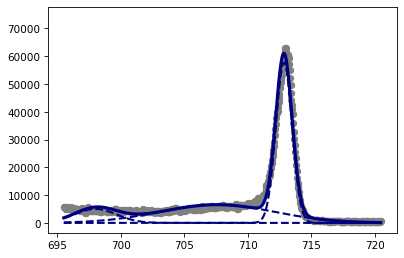

In [16]:
adapted_em.ani_gmm_history(dpi=75 ,save=True)